--- 1. DATASET OVERVIEW & SUMMARY STATISTICS ---
                 count         mean           std       min         25%  \
Age             1000.0     43.81900     14.991030     18.00     31.0000   
Annual_Income   1000.0  83812.84273  60017.741812  24278.57  40240.6675   
Years_Employed  1000.0     17.25400     10.124425      0.00      8.0000   
Prior_Default   1000.0      0.26300      0.440483      0.00      0.0000   
Credit_Score    1000.0    579.56400    155.516640    300.00    446.7500   
Approved        1000.0      0.50000      0.500250      0.00      0.0000   

                     50%         75%        max  
Age                44.00      56.000      69.00  
Annual_Income   66107.92  104396.165  470503.37  
Years_Employed     18.00      26.000      34.00  
Prior_Default       0.00       1.000       1.00  
Credit_Score      580.50     720.250     849.00  
Approved            0.50       1.000       1.00  


--- 2. CLASS BALANCE (APPROVAL RATIO) ---
Rejected applications: 50.00%
A

/tmp/ipykernel_637/1300746444.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Approved', y='Annual_Income', data=df, palette='Set2')


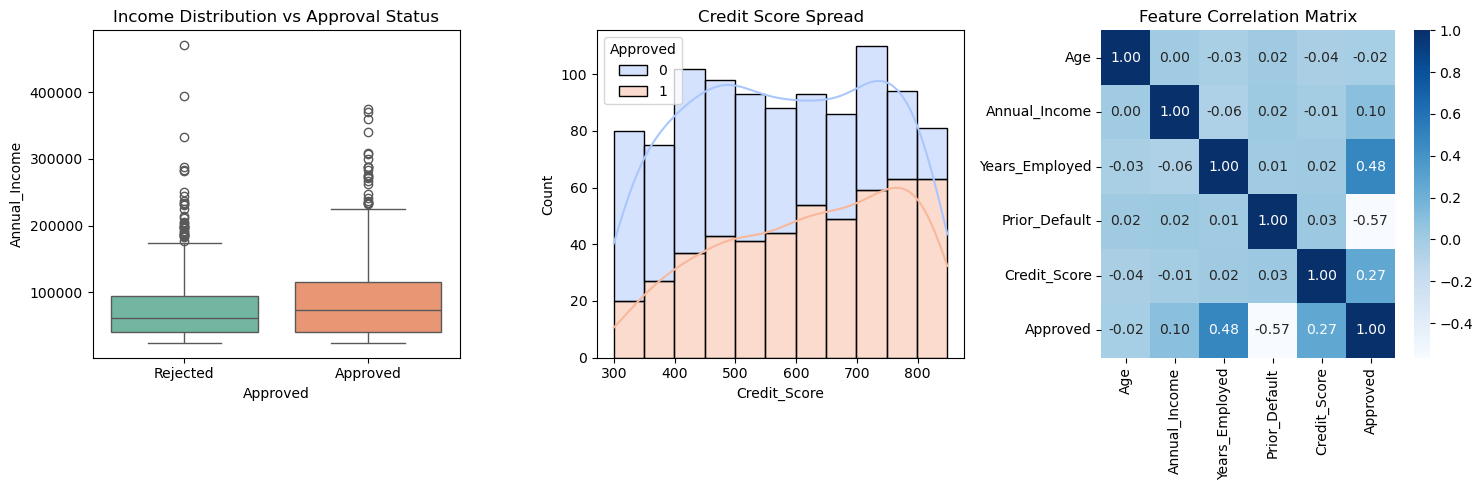

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
n_samples = 1000

# 1. Create a Realistic Credit Dataset
data = {
    'Applicant_ID': range(1001, 1001 + n_samples),
    'Age': np.random.randint(18, 70, size=n_samples),
    'Annual_Income': np.round(np.random.exponential(scale=60000, size=n_samples) + 24000, 2),
    'Years_Employed': np.random.randint(0, 35, size=n_samples),
    'Prior_Default': np.random.choice([0, 1], size=n_samples, p=[0.75, 0.25]),
    'Credit_Score': np.random.randint(300, 850, size=n_samples)
}

df = pd.DataFrame(data)

# Inject logic: Higher credit score + income & no default = High approval chance
score_metric = (df['Credit_Score'] * 0.4) + (df['Annual_Income'] / 2000) + (df['Years_Employed'] * 10) - (df['Prior_Default'] * 300)
df['Approved'] = np.where(score_metric > score_metric.median(), 1, 0)

# ==========================================
# DESCRIPTIVE ANALYSIS
# ==========================================

print("--- 1. DATASET OVERVIEW & SUMMARY STATISTICS ---")
print(df.drop(columns=['Applicant_ID']).describe().T)
print("\n" + "="*50 + "\n")

print("--- 2. CLASS BALANCE (APPROVAL RATIO) ---")
approval_counts = df['Approved'].value_counts(normalize=True) * 100
print(f"Rejected applications: {approval_counts[0]:.2f}%")
print(f"Approved applications: {approval_counts[1]:.2f}%")
print("\n" + "="*50 + "\n")

print("--- 3. DRILL-DOWN ANALYTICS BY APPROVAL STATUS ---")
# Aggregating metrics across approved vs rejected individuals
grouped_analysis = df.groupby('Approved').agg({
    'Annual_Income': ['mean', 'median'],
    'Credit_Score': 'mean',
    'Years_Employed': 'mean',
    'Prior_Default': 'sum'
}).rename(index={0: 'Rejected', 1: 'Approved'})
print(grouped_analysis)
print("\n" + "="*50 + "\n")

print("--- 4. CORRELATION WITH TARGET VARIABLE ---")
correlations = df.drop(columns=['Applicant_ID']).corr()['Approved'].sort_values(ascending=False)
print(correlations)

# ==========================================
# VISUALIZATION SUITE
# ==========================================
plt.figure(figsize=(15, 5))

# Plot 1: Income distribution by status
plt.subplot(1, 3, 1)
sns.boxplot(x='Approved', y='Annual_Income', data=df, palette='Set2')
plt.title('Income Distribution vs Approval Status')
plt.xticks([0, 1], ['Rejected', 'Approved'])

# Plot 2: Credit Score distribution by status
plt.subplot(1, 3, 2)
sns.histplot(data=df, x='Credit_Score', hue='Approved', kde=True, multiple='stack', palette='coolwarm')
plt.title('Credit Score Spread')

# Plot 3: Correlation Matrix Heatmap
plt.subplot(1, 3, 3)
sns.heatmap(df.drop(columns=['Applicant_ID']).corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()